# Major Project – Project 2: Loan Approval Prediction

**Student:** Shubham Sharma  
**Roll No.:** DSBA-T12/AUG-11445  
**Programme:** DSBA  
**Project Type:** Major Project  
**Domain:** Classification / Machine Learning

## Objective
Build classification models to predict whether a loan application is approved based on applicant demographic, financial, credit and property-related information.

### Models required
- Logistic Regression
- Decision Tree Classifier
- Random Forest Classifier
- Support Vector Machine (SVM)

### Evaluation
- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix
- ROC-AUC
- ROC Curve

The notebook also performs data cleaning, missing-value treatment, categorical encoding, class-imbalance analysis, EDA, model comparison and practical banking interpretation.

## 1. Dataset

This project uses the standard **Loan Prediction / Loan Eligibility dataset** containing 614 labelled loan applications and 13 columns including `Loan_ID`, applicant information, income, loan amount, credit history, property area and the target `Loan_Status`.

The target is:
- `Y` = Loan approved
- `N` = Loan not approved

The dataset structure is consistent with the public Loan Eligibility dataset documented by Kaggle and IBM's example.

In [1]:
print("Shubham Sharma DSBA-T12/AUG-11445")
print("Major Project - Project 2: Loan Approval Prediction")

Shubham Sharma DSBA-T12/AUG-11445
Major Project - Project 2: Loan Approval Prediction


In [30]:
# Import libraries
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

sns.set_theme(style="whitegrid")

## 2. Load the Dataset

The cell first attempts to load a public copy of the standard training dataset. If the internet copy is unavailable, it automatically asks for a CSV upload.

If you already have the dataset downloaded, you can upload it when prompted.

In [3]:
DATA_URLS = [
    "https://raw.githubusercontent.com/Paliking/ML_examples/master/LoanPrediction/train_u6lujuX_CVtuZ9i.csv",
    "https://raw.githubusercontent.com/Kamin-At/Loan_prediction/master/data/train_ctrUa4K.csv"
]

loan_df = None

for url in DATA_URLS:
    try:
        loan_df = pd.read_csv(url)
        print("Dataset loaded successfully from public source.")
        break
    except Exception as e:
        print("Source unavailable:", url)

if loan_df is None:
    from google.colab import files
    uploaded = files.upload()
    file_name = next(iter(uploaded))
    loan_df = pd.read_csv(file_name)

df = loan_df.copy()

print("Shape:", df.shape)
display(df.head())

Dataset loaded successfully from public source.
Shape: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.000,NaN,360.000,1.000,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,"1,508.000",128.000,360.000,1.000,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.000,66.000,360.000,1.000,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,"2,358.000",120.000,360.000,1.000,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.000,141.000,360.000,1.000,Urban,Y


In [4]:
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nDataset information:")
df.info()

Columns:
['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']

Data types:


,dtype
Loan_ID,object
Gender,object
Married,object
Dependents,object
Education,object
Self_Employed,object
ApplicantIncome,int64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,float64



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [5]:
# Missing values
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_table = pd.DataFrame({
    "Missing Values": missing,
    "Missing Percentage": missing_pct
})

display(missing_table[missing_table["Missing Values"] > 0])

print("Duplicate rows:", df.duplicated().sum())

,Missing Values,Missing Percentage
Credit_History,50,8.143
Self_Employed,32,5.212
LoanAmount,22,3.583
Dependents,15,2.443
Loan_Amount_Term,14,2.280
Gender,13,2.117
Married,3,0.489


Duplicate rows: 0


## 3. Target Variable and Class Imbalance

The target variable `Loan_Status` is converted into a binary label:
- Approved (`Y`) → 1
- Not Approved (`N`) → 0

The class distribution is examined before modeling. This is important because a model can appear accurate while performing poorly on the minority class.

,Count,Percentage
Not Approved (0),192,31.270
Approved (1),422,68.730


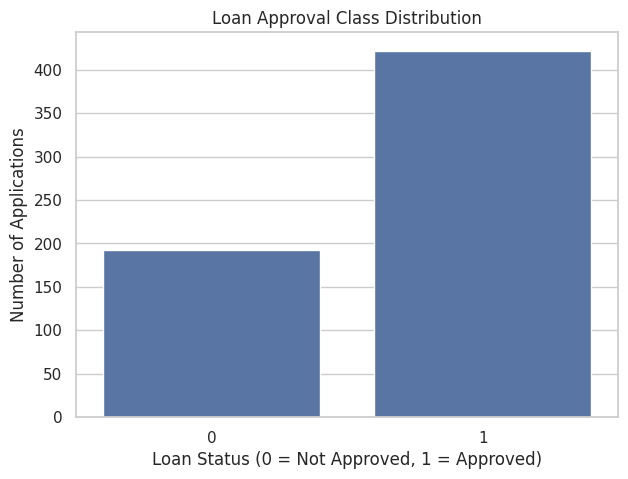

In [6]:
df["Loan_Status"] = df["Loan_Status"].map({"Y": 1, "N": 0})

class_counts = df["Loan_Status"].value_counts().sort_index()
class_pct = df["Loan_Status"].value_counts(normalize=True).sort_index() * 100

class_table = pd.DataFrame({
    "Count": class_counts,
    "Percentage": class_pct
})

class_table.index = ["Not Approved (0)", "Approved (1)"]

display(class_table)

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Loan_Status")
plt.title("Loan Approval Class Distribution")
plt.xlabel("Loan Status (0 = Not Approved, 1 = Approved)")
plt.ylabel("Number of Applications")
plt.show()

## 4. Data Cleaning and Feature Engineering

`Loan_ID` is an identifier and is not useful as a predictive feature, so it is removed.

The `Dependents` field contains a `3+` category. It is converted to 3 so that it can be treated as an ordinal numerical feature.

A new feature, `TotalIncome`, combines applicant and co-applicant income.

In [7]:
data = df.copy()

# Remove identifier
data = data.drop(columns=["Loan_ID"], errors="ignore")

# Convert Dependents to numerical representation
data["Dependents"] = data["Dependents"].replace("3+", 3)
data["Dependents"] = pd.to_numeric(data["Dependents"], errors="coerce")

# Create total income
data["TotalIncome"] = data["ApplicantIncome"] + data["CoapplicantIncome"]

display(data.head())

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome
0,Male,No,0.000,Graduate,No,5849,0.000,NaN,360.000,1.000,Urban,1,"5,849.000"
1,Male,Yes,1.000,Graduate,No,4583,"1,508.000",128.000,360.000,1.000,Rural,0,"6,091.000"
2,Male,Yes,0.000,Graduate,Yes,3000,0.000,66.000,360.000,1.000,Urban,1,"3,000.000"
3,Male,Yes,0.000,Not Graduate,No,2583,"2,358.000",120.000,360.000,1.000,Urban,1,"4,941.000"
4,Male,No,0.000,Graduate,No,6000,0.000,141.000,360.000,1.000,Urban,1,"6,000.000"


## 5. Exploratory Data Analysis

The following analysis examines:
- Approval distribution
- Gender vs approval
- Marital status vs approval
- Education vs approval
- Employment status vs approval
- Property area vs approval
- Credit history vs approval
- Income distributions
- Loan amount distributions
- Numerical correlation matrix
- Approval rate by income groups

These plots provide both statistical and business context for the classification task.

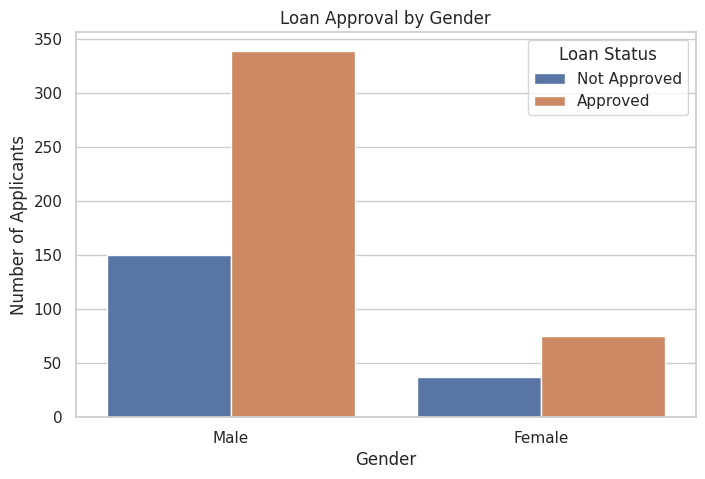

In [8]:
plt.figure(figsize=(8, 5))
sns.countplot(data=data, x="Gender", hue="Loan_Status")
plt.title("Loan Approval by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Applicants")
plt.legend(title="Loan Status", labels=["Not Approved", "Approved"])
plt.show()

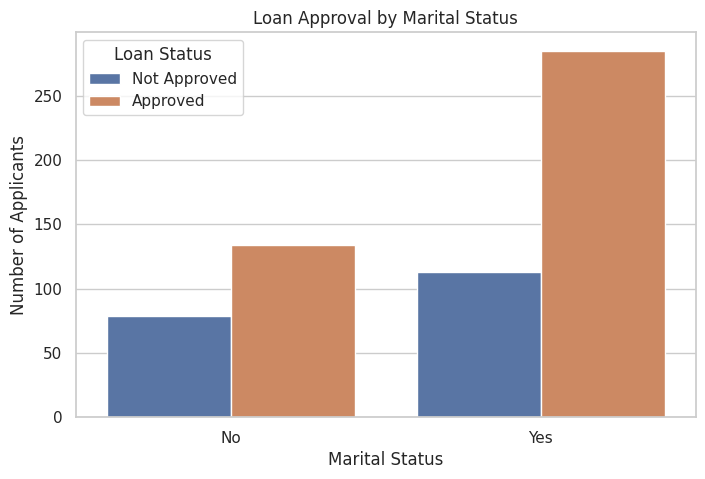

In [9]:
plt.figure(figsize=(8, 5))
sns.countplot(data=data, x="Married", hue="Loan_Status")
plt.title("Loan Approval by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Number of Applicants")
plt.legend(title="Loan Status", labels=["Not Approved", "Approved"])
plt.show()

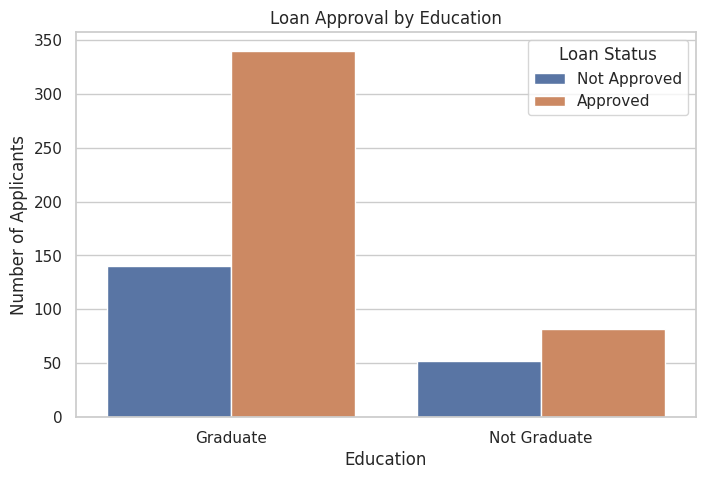

In [10]:
plt.figure(figsize=(8, 5))
sns.countplot(data=data, x="Education", hue="Loan_Status")
plt.title("Loan Approval by Education")
plt.xlabel("Education")
plt.ylabel("Number of Applicants")
plt.legend(title="Loan Status", labels=["Not Approved", "Approved"])
plt.show()

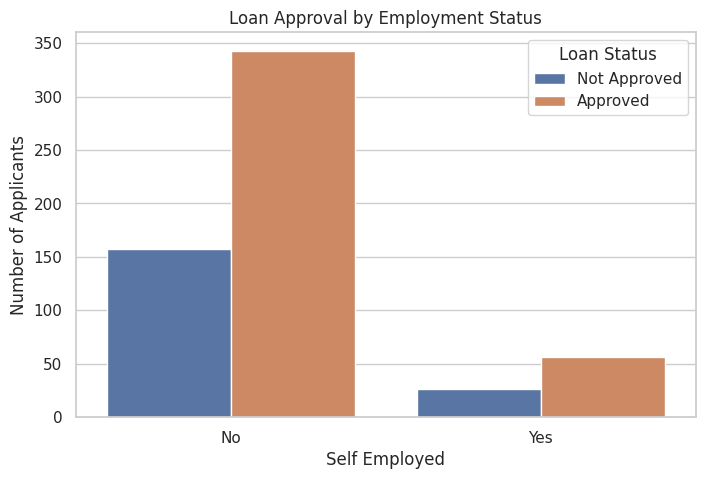

In [11]:
plt.figure(figsize=(8, 5))
sns.countplot(data=data, x="Self_Employed", hue="Loan_Status")
plt.title("Loan Approval by Employment Status")
plt.xlabel("Self Employed")
plt.ylabel("Number of Applicants")
plt.legend(title="Loan Status", labels=["Not Approved", "Approved"])
plt.show()

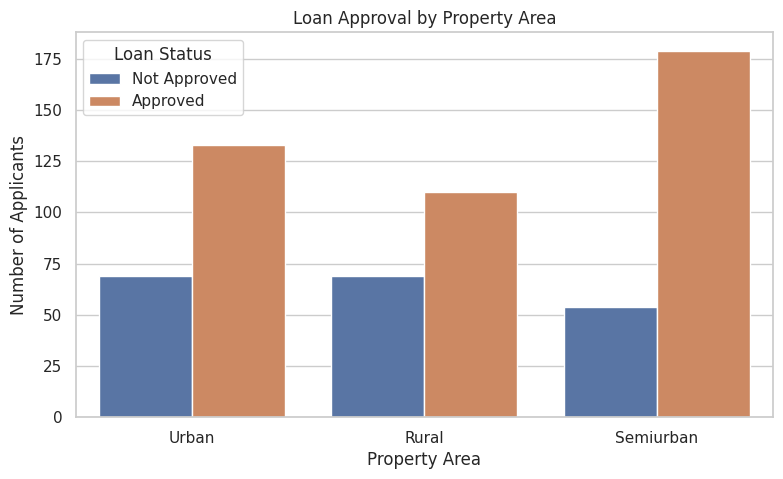

In [12]:
plt.figure(figsize=(9, 5))
sns.countplot(data=data, x="Property_Area", hue="Loan_Status")
plt.title("Loan Approval by Property Area")
plt.xlabel("Property Area")
plt.ylabel("Number of Applicants")
plt.legend(title="Loan Status", labels=["Not Approved", "Approved"])
plt.show()

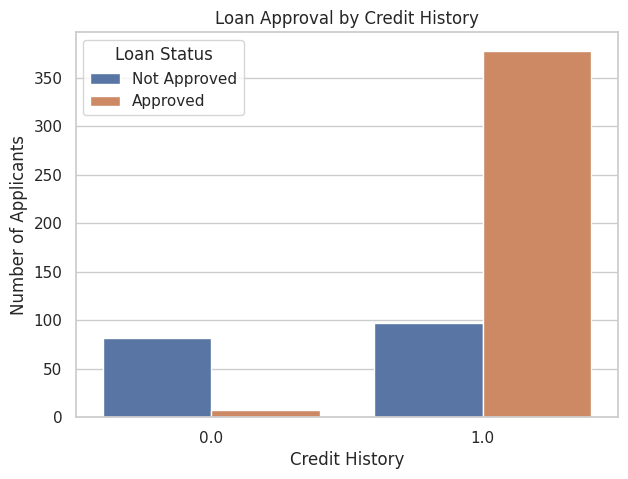

In [13]:
plt.figure(figsize=(7, 5))
sns.countplot(data=data, x="Credit_History", hue="Loan_Status")
plt.title("Loan Approval by Credit History")
plt.xlabel("Credit History")
plt.ylabel("Number of Applicants")
plt.legend(title="Loan Status", labels=["Not Approved", "Approved"])
plt.show()

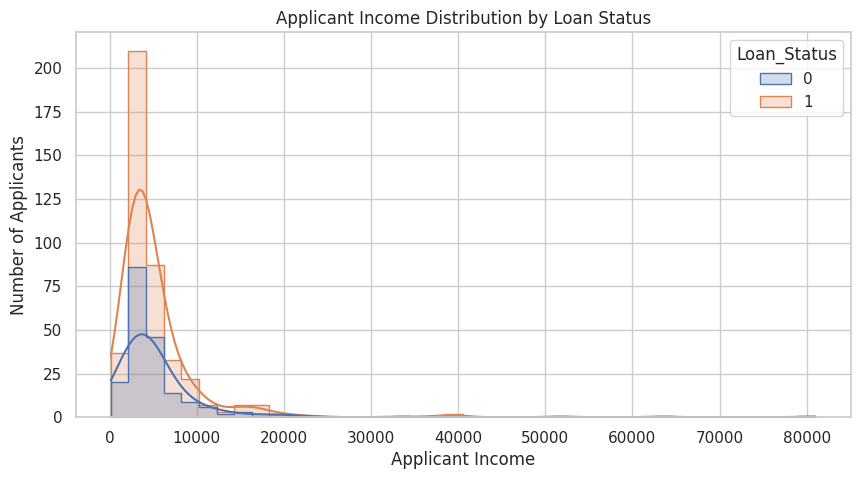

In [14]:
plt.figure(figsize=(10, 5))
sns.histplot(data=data, x="ApplicantIncome", hue="Loan_Status", bins=40, kde=True, element="step")
plt.title("Applicant Income Distribution by Loan Status")
plt.xlabel("Applicant Income")
plt.ylabel("Number of Applicants")
plt.show()

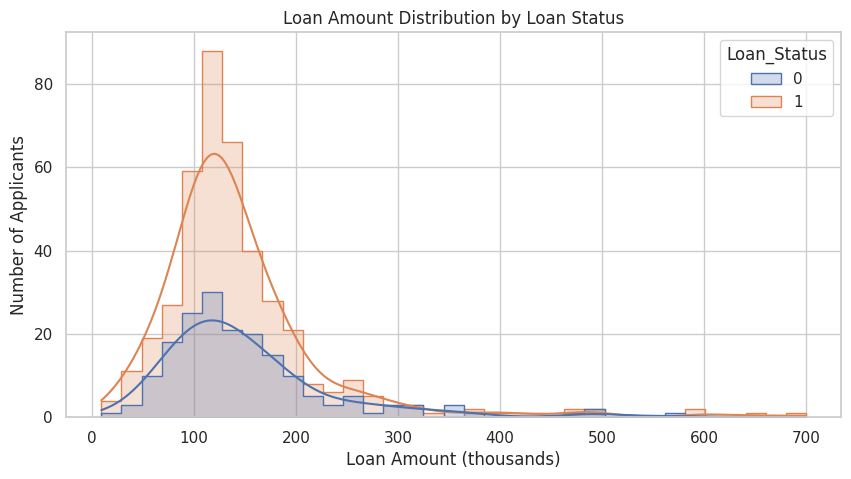

In [15]:
plt.figure(figsize=(10, 5))
sns.histplot(data=data, x="LoanAmount", hue="Loan_Status", bins=35, kde=True, element="step")
plt.title("Loan Amount Distribution by Loan Status")
plt.xlabel("Loan Amount (thousands)")
plt.ylabel("Number of Applicants")
plt.show()

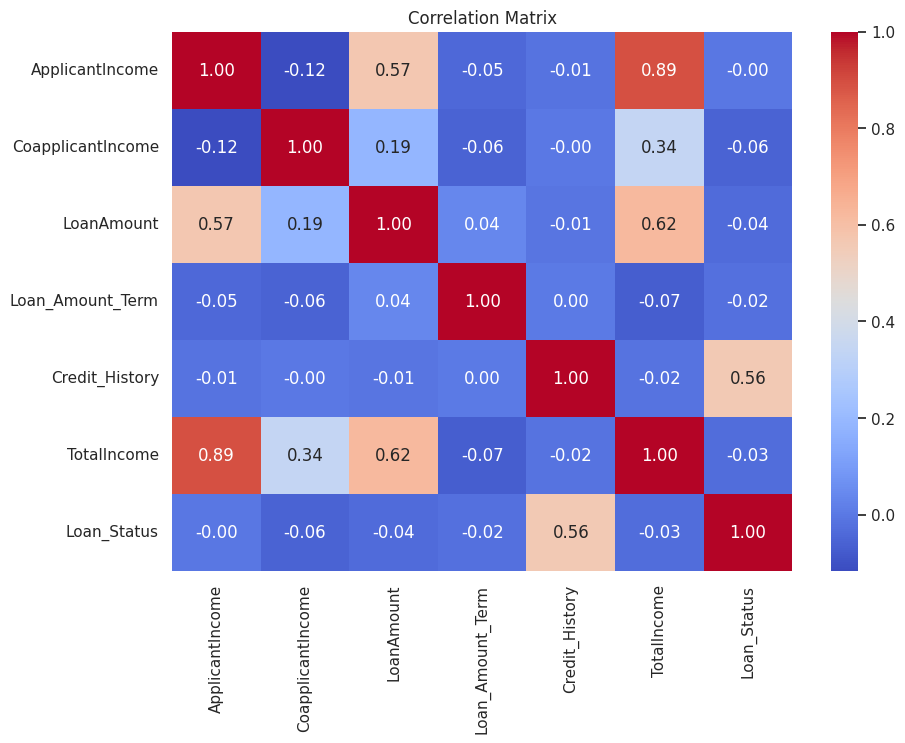

In [16]:
numeric_eda = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term",
    "Credit_History",
    "TotalIncome",
    "Loan_Status"
]

plt.figure(figsize=(10, 7))
sns.heatmap(data[numeric_eda].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

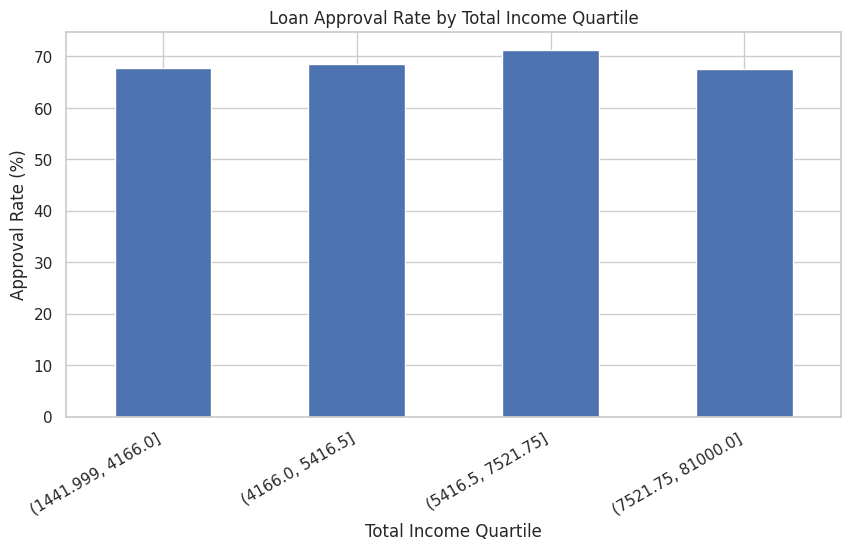

,Approval Rate (%)
TotalIncome,
"(1441.999, 4166.0]",67.742
"(4166.0, 5416.5]",68.421
"(5416.5, 7521.75]",71.242
"(7521.75, 81000.0]",67.532


In [17]:
# Approval rate by income quartile
income_groups = pd.qcut(data["TotalIncome"], q=4, duplicates="drop")
approval_by_income = data.groupby(income_groups, observed=False)["Loan_Status"].mean() * 100

plt.figure(figsize=(10, 5))
approval_by_income.plot(kind="bar")
plt.title("Loan Approval Rate by Total Income Quartile")
plt.xlabel("Total Income Quartile")
plt.ylabel("Approval Rate (%)")
plt.xticks(rotation=30, ha="right")
plt.show()

display(approval_by_income.to_frame("Approval Rate (%)"))

## 6. Train/Test Split and Preprocessing

The data is split into training and testing sets using stratification so that the class proportions are preserved.

Categorical features are one-hot encoded and numerical features are median-imputed and standardized. Preprocessing is placed inside pipelines to prevent data leakage from the test set.

In [18]:
X = data.drop(columns=["Loan_Status"])
y = data["Loan_Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

categorical_features = [
    "Gender",
    "Married",
    "Education",
    "Self_Employed",
    "Property_Area"
]

numeric_features = [
    "Dependents",
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term",
    "Credit_History",
    "TotalIncome"
]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

Training samples: 491
Testing samples : 123


## 7. Evaluation Function

The same evaluation function is applied to every classifier. This ensures that the models are compared using identical test data and metrics.

In [19]:
def evaluate_classifier(name, model, X_test, y_test):
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_score)
    }

    print(f"\n{name}")
    print("-" * len(name))
    print(classification_report(
        y_test, y_pred,
        target_names=["Not Approved", "Approved"],
        zero_division=0
    ))

    return metrics, y_pred, y_score

## 8. Model 1 – Logistic Regression

In [20]:
logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

logistic_metrics, logistic_pred, logistic_score = evaluate_classifier(
    "Logistic Regression",
    logistic_model,
    X_test,
    y_test
)


Logistic Regression
-------------------
              precision    recall  f1-score   support

Not Approved       0.96      0.58      0.72        38
    Approved       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123



## 9. Model 2 – Decision Tree Classifier

In [21]:
tree_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf=5,
        random_state=42
    ))
])

tree_model.fit(X_train, y_train)

tree_metrics, tree_pred, tree_score = evaluate_classifier(
    "Decision Tree",
    tree_model,
    X_test,
    y_test
)


Decision Tree
-------------
              precision    recall  f1-score   support

Not Approved       0.86      0.63      0.73        38
    Approved       0.85      0.95      0.90        85

    accuracy                           0.85       123
   macro avg       0.85      0.79      0.81       123
weighted avg       0.85      0.85      0.85       123



## 10. Model 3 – Random Forest Classifier

In [22]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ))
])

rf_model.fit(X_train, y_train)

rf_metrics, rf_pred, rf_score = evaluate_classifier(
    "Random Forest",
    rf_model,
    X_test,
    y_test
)


Random Forest
-------------
              precision    recall  f1-score   support

Not Approved       0.74      0.66      0.69        38
    Approved       0.85      0.89      0.87        85

    accuracy                           0.82       123
   macro avg       0.79      0.78      0.78       123
weighted avg       0.82      0.82      0.82       123



## 11. Model 4 – Support Vector Machine (SVM)

In [23]:
svm_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", SVC(
        kernel="rbf",
        C=1.0,
        probability=True,
        class_weight="balanced",
        random_state=42
    ))
])

svm_model.fit(X_train, y_train)

svm_metrics, svm_pred, svm_score = evaluate_classifier(
    "Support Vector Machine",
    svm_model,
    X_test,
    y_test
)


Support Vector Machine
----------------------
              precision    recall  f1-score   support

Not Approved       0.85      0.61      0.71        38
    Approved       0.84      0.95      0.90        85

    accuracy                           0.85       123
   macro avg       0.85      0.78      0.80       123
weighted avg       0.85      0.85      0.84       123



## 12. Model Comparison

In [24]:
results = pd.DataFrame([
    logistic_metrics,
    tree_metrics,
    rf_metrics,
    svm_metrics
])

display(
    results.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1 Score": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8618,0.8400,0.9882,0.9081,0.8486
1,Decision Tree,0.8537,0.8526,0.9529,0.9000,0.8296
2,Random Forest,0.8211,0.8539,0.8941,0.8736,0.8260
3,Support Vector Machine,0.8455,0.8438,0.9529,0.8950,0.8316


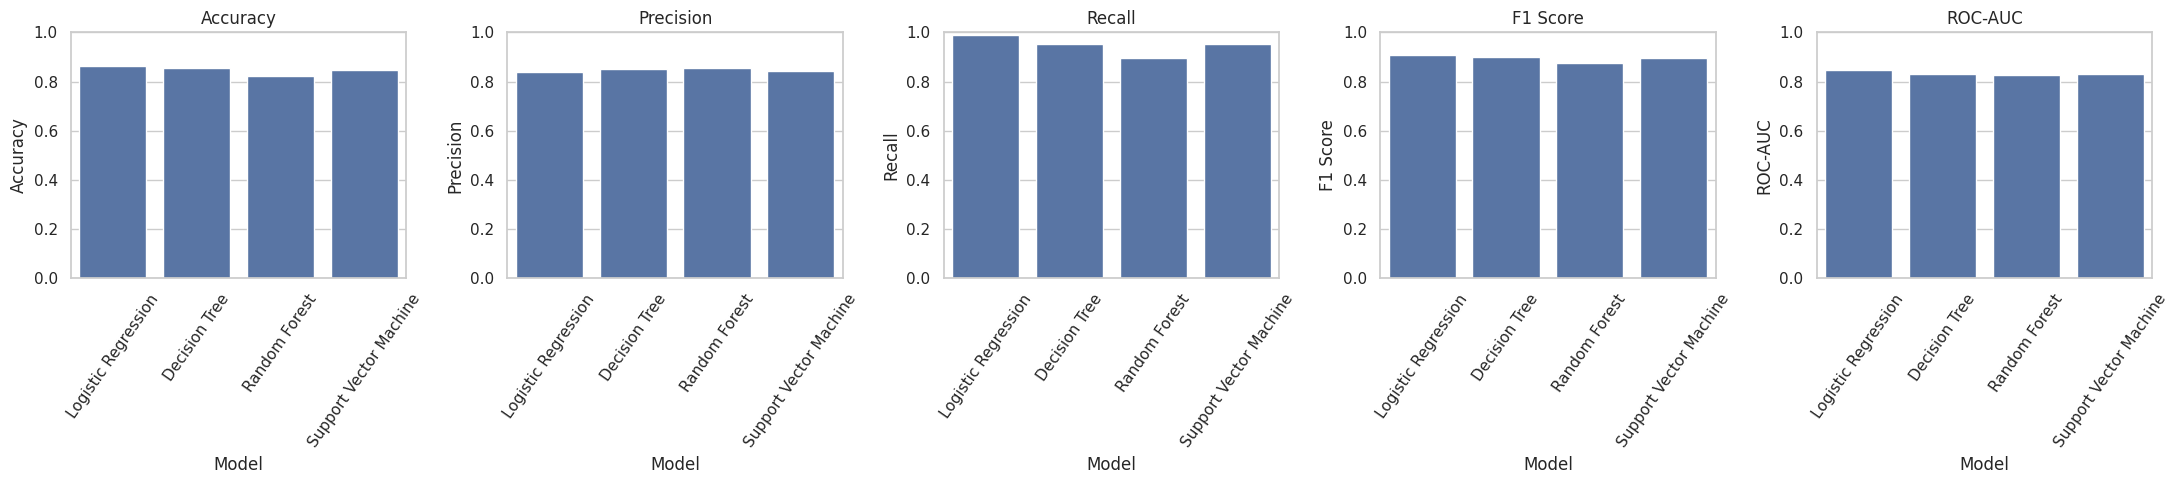

In [25]:
# Visual comparison
plot_metrics = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]

fig, axes = plt.subplots(1, 5, figsize=(22, 5))

for ax, metric in zip(axes, plot_metrics):
    sns.barplot(data=results, x="Model", y=metric, ax=ax)
    ax.set_title(metric)
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=55)

plt.tight_layout()
plt.show()

## 13. Confusion Matrices

A confusion matrix shows:
- True Negatives: correctly predicted rejected applications
- False Positives: rejected applications predicted as approved
- False Negatives: approved applications predicted as rejected
- True Positives: correctly predicted approved applications

In a banking context, both false approvals and false rejections have practical consequences.

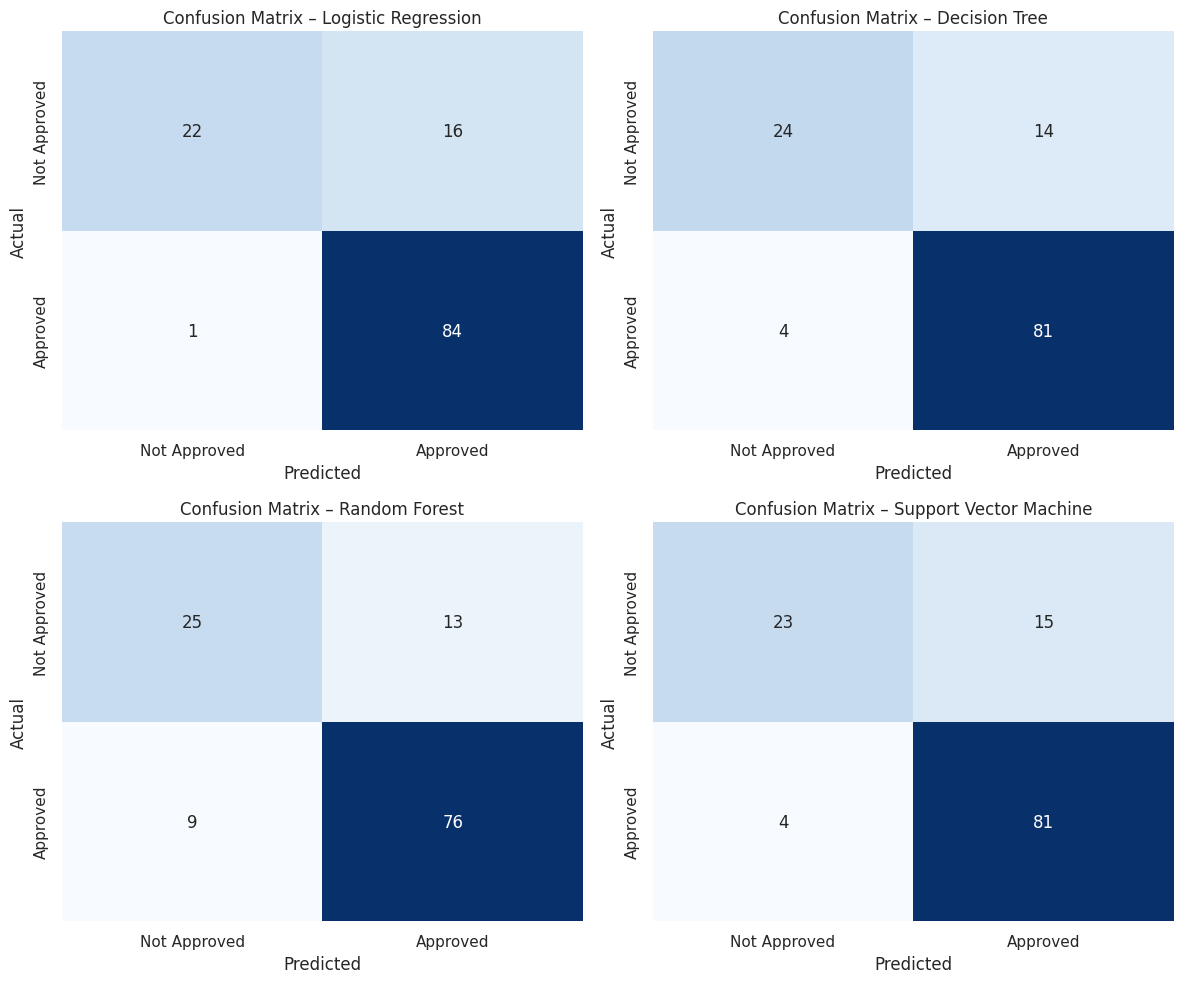

In [26]:
model_predictions = {
    "Logistic Regression": logistic_pred,
    "Decision Tree": tree_pred,
    "Random Forest": rf_pred,
    "Support Vector Machine": svm_pred
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for ax, (name, pred) in zip(axes, model_predictions.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax,
        xticklabels=["Not Approved", "Approved"],
        yticklabels=["Not Approved", "Approved"]
    )
    ax.set_title(f"Confusion Matrix – {name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

## 14. ROC Curves and ROC-AUC

The ROC curve plots the True Positive Rate against the False Positive Rate at different classification thresholds.

ROC-AUC summarizes the model's ability to distinguish between approved and not-approved applications across thresholds.

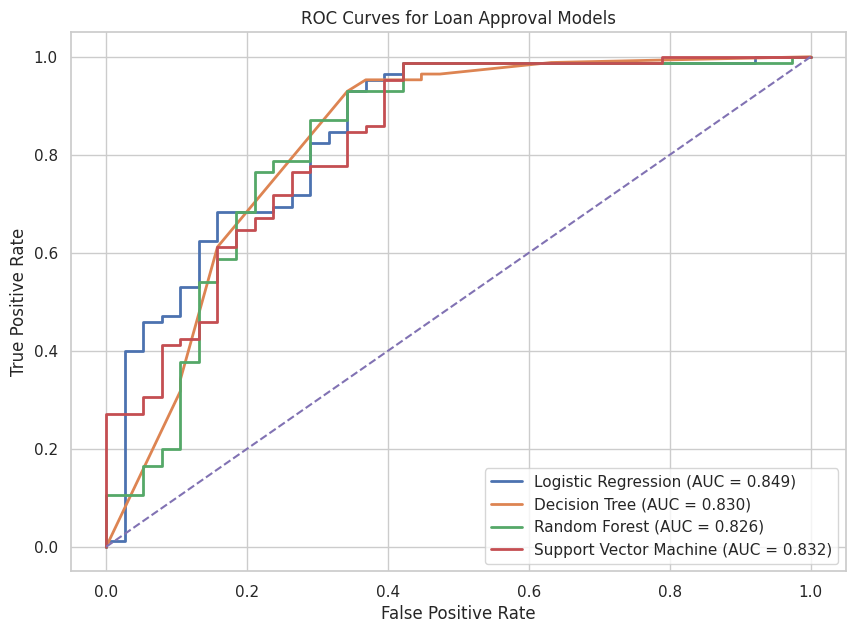

In [27]:
roc_data = {
    "Logistic Regression": logistic_score,
    "Decision Tree": tree_score,
    "Random Forest": rf_score,
    "Support Vector Machine": svm_score
}

plt.figure(figsize=(10, 7))

for name, score in roc_data.items():
    fpr, tpr, _ = roc_curve(y_test, score)
    auc_value = roc_auc_score(y_test, score)
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {auc_value:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Loan Approval Models")
plt.legend()
plt.show()

## 15. Feature Importance – Random Forest

Random Forest feature importance is extracted after preprocessing. One-hot encoded categorical features are aggregated back to their original feature groups so the results can be interpreted more easily.

In [28]:
# Fit preprocessing separately to recover feature names
X_train_transformed = preprocessor.fit_transform(X_train)

rf_plain = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_plain.fit(X_train_transformed, y_train)

feature_names = preprocessor.get_feature_names_out()
raw_importances = pd.Series(
    rf_plain.feature_importances_,
    index=feature_names
)

aggregated_importance = {}

for feature, importance in raw_importances.items():
    clean = feature.replace("num__", "").replace("cat__", "")

    if clean.startswith("Gender_"):
        base = "Gender"
    elif clean.startswith("Married_"):
        base = "Married"
    elif clean.startswith("Education_"):
        base = "Education"
    elif clean.startswith("Self_Employed_"):
        base = "Self_Employed"
    elif clean.startswith("Property_Area_"):
        base = "Property_Area"
    else:
        base = clean

    aggregated_importance[base] = aggregated_importance.get(base, 0) + importance

top_features = (
    pd.Series(aggregated_importance)
    .sort_values(ascending=False)
    .head(5)
)

display(top_features.to_frame("Aggregated Importance"))

,Aggregated Importance
Credit_History,0.316
ApplicantIncome,0.132
TotalIncome,0.129
LoanAmount,0.125
CoapplicantIncome,0.080


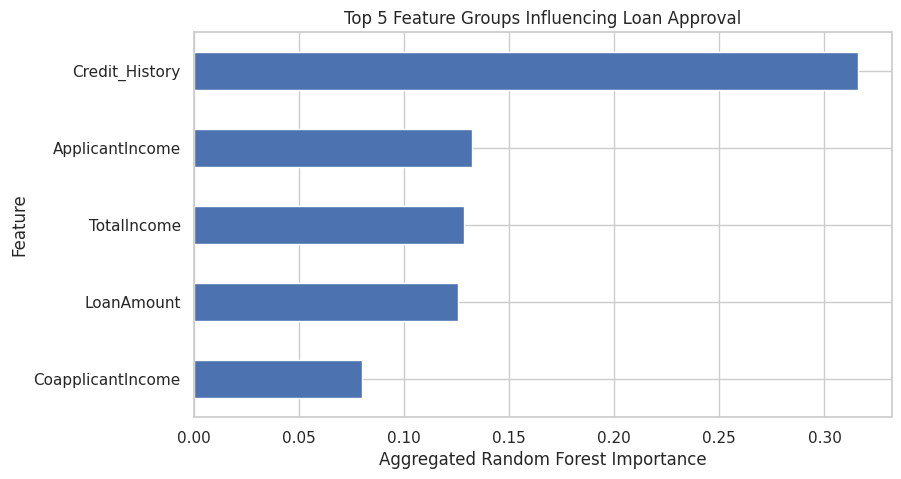

In [29]:
plt.figure(figsize=(9, 5))
top_features.sort_values().plot(kind="barh")
plt.title("Top 5 Feature Groups Influencing Loan Approval")
plt.xlabel("Aggregated Random Forest Importance")
plt.ylabel("Feature")
plt.show()

## 16. Practical Banking Interpretation

A loan approval prediction model can be used as a decision-support system to help prioritize applications for manual review.

Important considerations:
- Credit history can provide strong information about repayment-related eligibility.
- Income and requested loan amount help represent the financial profile of an applicant.
- Demographic and property-related fields may contribute additional predictive information.
- The model should support, not blindly replace, responsible lending review.
- Thresholds should be selected according to the bank's risk tolerance and the relative cost of false approvals versus false rejections.
- Fairness, explainability, regulatory requirements and human oversight are important in real-world deployment.

## 17. Conclusion

This project implemented an end-to-end loan approval classification workflow. The process included data exploration, missing-value analysis, class-imbalance analysis, feature engineering, categorical encoding, numerical scaling and four classification algorithms.

Logistic Regression, Decision Tree, Random Forest and SVM were evaluated using Accuracy, Precision, Recall, F1 Score and ROC-AUC. Confusion matrices and ROC curves were also generated to examine classification behaviour beyond simple accuracy.

The final report should use the exact metrics produced by this notebook and explain the model comparison using the banking context. No performance value should be manually invented.

## References

1. Kaggle – Loan Eligibility Prediction dataset.
2. IBM – Predict Loan Eligibility using IBM Watson Studio.
3. Scikit-learn documentation – classification algorithms, preprocessing and evaluation metrics.
4. Major Project – August 2026 Batch DSBA project guideline.